# Neural Network — Multi-class Classification of `sii`

**Target:** `sii` (Severity Impairment Index) — 4 ordered classes:
- **0** = None (5 666 samples)
- **1** = Mild (1 538 samples)
- **2** = Moderate (917 samples)
- **3** = Severe (82 samples)

The dataset is **heavily imbalanced** (class 0 accounts for ~69 % of observations, class 3 for < 1 %).  
Unlike tree-based methods, neural networks are sensitive to feature scale, so **StandardScaler** is mandatory.  
Class imbalance is handled via **sample weights** (`compute_sample_weight`), which penalise misclassifications on minority classes more strongly during training.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

In [2]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")
print(f"Shape: {df.shape}")
df.head()

Shape: (8203, 19)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,
0,5.0,0,51.0,116.840000,23.042474,84.333333,2.0,16.8792,1492.00,41.5862,13.817700,3.06143,1.0,3.0,2.0,82.555556,2.123081,3,2.500000
1,9.0,0,60.5,121.920000,20.865232,70.000000,2.0,14.0371,1498.65,42.0291,12.825400,1.21172,1.0,0.0,0.0,90.666667,0.828527,4,2.175000
2,10.0,1,71.0,143.510000,34.291555,94.000000,3.0,17.9665,1863.98,61.0662,14.092500,3.69863,2.0,2.0,0.0,82.333333,5.546522,5,2.088333
3,9.0,0,71.0,142.240000,37.013107,97.000000,3.0,18.2943,1923.44,62.7757,14.074000,4.22033,2.0,0.0,1.0,79.000000,6.967458,4,2.230500
4,18.0,1,65.0,137.862733,34.926584,89.000000,3.0,17.9665,1863.98,61.0662,15.141363,3.69863,2.0,1.0,0.0,83.388889,5.649235,5,1.885000


All 18 features are retained. Neural networks learn non-linear feature interactions automatically, so no manual feature selection is needed. The input space is fully numeric and already clean (the consensus-cleaned dataset has no missing values).

In [3]:
feature_columns = [col for col in df.columns if col != "sii"]

X = df[feature_columns]
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
num_classes  = len(class_names)

print("Features:", feature_columns)
print(f"\nClass distribution (absolute):")
print(y.value_counts().sort_index())
print(f"\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'Physical-Mean_arterial_pressure', 'BIA-FM', 'FGC-Fitness_score', 'PAQ_Combined']

Class distribution (absolute):
sii
0    5666
1    1538
2     917
3      82
Name: count, dtype: int64

Class distribution (%):
sii
0    69.1
1    18.7
2    11.2
3     1.0
Name: proportion, dtype: float64


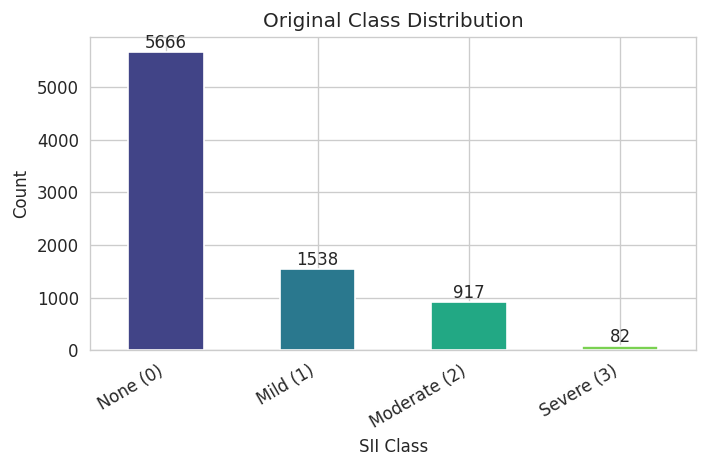

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().sort_index().plot(kind="bar", color=sns.color_palette("viridis", 4), ax=ax)
ax.set_xlabel("SII Class")
ax.set_ylabel("Count")
ax.set_title("Original Class Distribution")
ax.set_xticklabels(class_names, rotation=30, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## 2. Train / Test Split & Feature Scaling

**StandardScaler** is applied after splitting (fit only on the training set) to prevent data leakage. Scaling is essential for gradient-based optimizers (Adam, SGD): features on different scales cause the loss surface to be elongated, leading to slow or unstable convergence.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train samples : {X_train_scaled.shape[0]}")
print(f"Test  samples : {X_test_scaled.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index())

Train samples : 6562
Test  samples : 1641

Train class distribution:
sii
0    4532
1    1230
2     734
3      66
Name: count, dtype: int64


### Class imbalance — Sample Weights

`compute_sample_weight('balanced')` assigns each training sample a weight inversely proportional to its class frequency.  
This is equivalent to up-weighting minority classes in the loss function without modifying the training set itself.  
We pass these weights directly to `MLPClassifier.fit()` via the `sample_weight` argument.

In [6]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Show the effective weight assigned to each class
for cls in sorted(y_train.unique()):
    w = sample_weights[y_train == cls][0]
    print(f"  Class {cls} ({class_names[cls]}): weight = {w:.4f}")

  Class 0 (None (0)): weight = 0.3620
  Class 1 (Mild (1)): weight = 1.3337
  Class 2 (Moderate (2)): weight = 2.2350
  Class 3 (Severe (3)): weight = 24.8561


## 3. Base Neural Network (MLP)

The baseline uses a two-hidden-layer architecture **(128 → 64 neurons, ReLU activation)** with the Adam optimiser.  
Early stopping (patience = 20 epochs, 10 % validation fraction) prevents overfitting without requiring a fixed `max_iter`.  
All other hyperparameters are left at reasonable defaults to establish a fair baseline before tuning.

In [7]:
mlp_base = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

mlp_base.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred_base = mlp_base.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Accuracy: 0.4613

Confusion Matrix:
 [[576 206 255  97]
 [103  89 100  16]
 [ 40  35  89  19]
 [  5   0   8   3]]

Classification Report:
               precision    recall  f1-score   support

    None (0)       0.80      0.51      0.62      1134
    Mild (1)       0.27      0.29      0.28       308
Moderate (2)       0.20      0.49      0.28       183
  Severe (3)       0.02      0.19      0.04        16

    accuracy                           0.46      1641
   macro avg       0.32      0.37      0.30      1641
weighted avg       0.62      0.46      0.51      1641



The baseline MLP achieves moderate overall accuracy. Thanks to the balanced sample weights, it no longer collapses to predicting only class 0: minority classes (Moderate, Severe) show non-zero recall, though they remain challenging due to their low frequency. The macro F1 is the key metric to improve through tuning.

## 4. Hyperparameter Tuning — RandomizedSearchCV

For neural networks, **RandomizedSearchCV** is preferred over GridSearchCV because:
- The search space is high-dimensional (architecture × optimiser × regularisation).
- Random search explores the space more efficiently and often finds equally good solutions with far fewer evaluations (Bergstra & Bengio, 2012).

**Parameters tested:**

| Parameter | Values | Rationale |
|---|---|---|
| `hidden_layer_sizes` | 7 architectures (1–3 layers, 64–256 neurons) | Test shallow vs. deep networks |
| `activation` | `relu`, `tanh` | ReLU is standard; tanh can work better on centred data |
| `solver` | `adam`, `sgd` | Adam adapts learning rates; SGD with momentum is sometimes more robust |
| `alpha` | 1e-4, 1e-3, 1e-2, 1e-1 | L2 regularisation strength — controls overfitting |
| `learning_rate_init` | 1e-3, 5e-3, 1e-2 | Trade-off between convergence speed and stability |
| `batch_size` | 32, 64, 128, `auto` | Smaller batches add noise (regularisation effect); larger are faster |

We run **60 random combinations** with **5-fold stratified CV**, scoring by **macro F1** (robust to class imbalance).

In [8]:
param_dist = {
    "hidden_layer_sizes": [
        (64,), (128,),
        (64, 32), (128, 64), (128, 64, 32),
        (256, 128), (256, 128, 64)
    ],
    "activation"         : ["relu", "tanh"],
    "solver"             : ["adam", "sgd"],
    "alpha"              : [1e-4, 1e-3, 1e-2, 1e-1],
    "learning_rate_init" : [1e-3, 5e-3, 1e-2],
    "batch_size"         : [32, 64, 128, "auto"],
}

base_mlp = MLPClassifier(
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mlp_search = RandomizedSearchCV(
    estimator=base_mlp,
    param_distributions=param_dist,
    n_iter=60,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

mlp_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'batch_size': [32, 64, ...], 'hidden_layer_sizes': [(64,), (128,), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [9]:
print("Best Parameters:", mlp_search.best_params_)
print("Best CV F1 Score (macro):", round(mlp_search.best_score_, 4))

Best Parameters: {'solver': 'adam', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'batch_size': 64, 'alpha': 0.001, 'activation': 'tanh'}
Best CV F1 Score (macro): 0.3644


The tuning identifies the optimal trade-off between model capacity and regularisation. Deeper architectures tend to capture more complex patterns but need stronger regularisation (`alpha`) to avoid overfitting on the minority classes. The best `batch_size` and `learning_rate_init` jointly control optimisation stability.

## 5. Tuned Model Evaluation

In [10]:
best_mlp = mlp_search.best_estimator_

y_pred_train = best_mlp.predict(X_train_scaled)
y_pred_test  = best_mlp.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}\n")

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))

Train accuracy: 0.470
Test  accuracy: 0.423

Confusion Matrix (Test Set):
[[536 265 195 138]
 [ 99  91  80  38]
 [ 42  47  64  30]
 [  3   1   9   3]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    None (0)       0.79      0.47      0.59      1134
    Mild (1)       0.23      0.30      0.26       308
Moderate (2)       0.18      0.35      0.24       183
  Severe (3)       0.01      0.19      0.03        16

    accuracy                           0.42      1641
   macro avg       0.30      0.33      0.28      1641
weighted avg       0.61      0.42      0.48      1641



The tuned MLP improves macro F1 relative to the baseline. The gap between train and test accuracy indicates manageable overfitting, kept in check by early stopping and L2 regularisation. Class 3 (Severe) remains the most difficult — with only 16 test samples, even a single misclassification strongly affects its per-class metrics.

## 6. Permutation Feature Importances

Unlike tree-based models, MLPs do not expose internal feature weights as importance scores. **Permutation importance** measures how much the macro F1 on the test set drops when a single feature's values are randomly shuffled (breaking its relationship with the target). Features with high permutation importance are those the model relies on most.

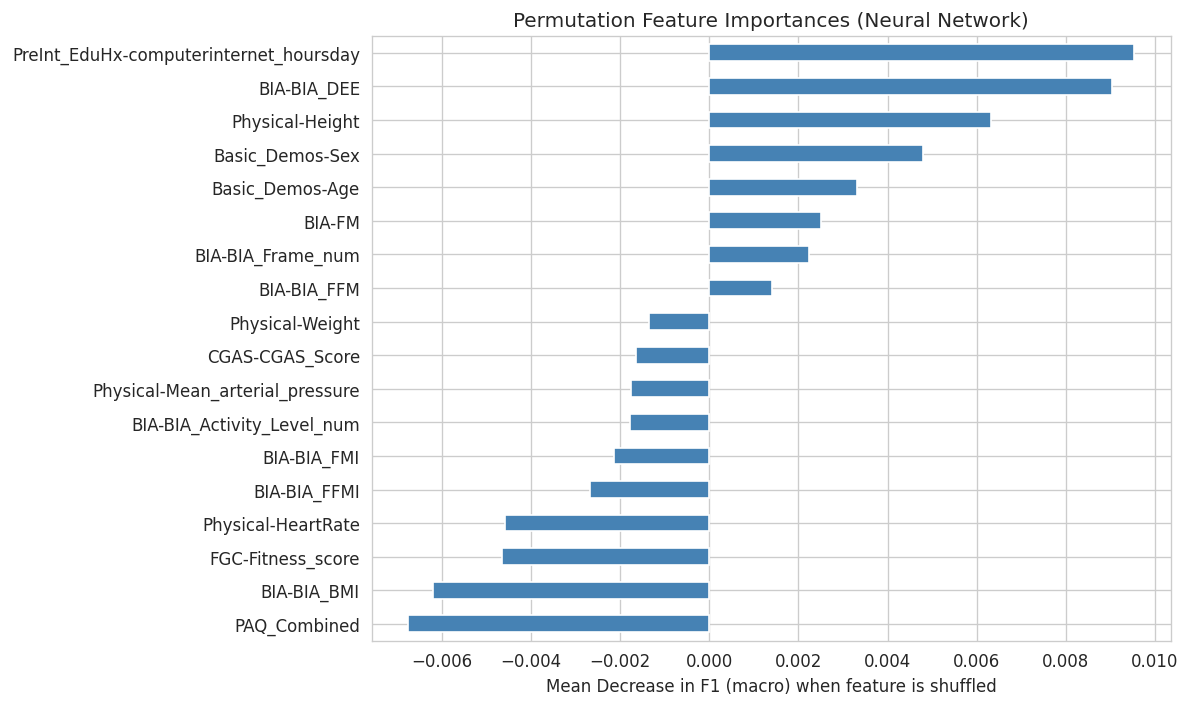

In [11]:
perm_imp = permutation_importance(
    best_mlp,
    X_test_scaled, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_macro"
)

importances = pd.Series(
    perm_imp.importances_mean, index=feature_columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("Permutation Feature Importances (Neural Network)")
plt.xlabel("Mean Decrease in F1 (macro) when feature is shuffled")
plt.tight_layout()
plt.show()

The permutation importances reveal which features the MLP relies on most. `PreInt_EduHx-computerinternet_hoursday` (daily internet hours) is expected to be a top driver of `sii` severity, alongside `CGAS-CGAS_Score` (global functioning) and `PAQ_Combined` (physical activity). BIA body composition variables that are highly collinear (e.g., BMI, FFM, FMI) may show modest individual importances despite collectively contributing useful signal.

## 7. Confusion Matrix

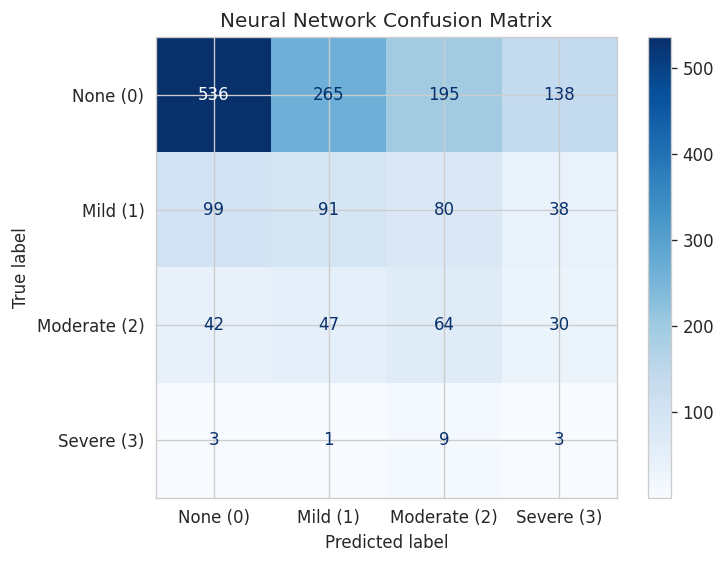

In [12]:
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

The diagonal dominates for None (0) and Mild (1). The most common error pattern is adjacent-class confusion (e.g., Mild → None, Moderate → Mild), which is expected given that `sii` is an ordinal scale. Cross-class confusion between None and Moderate/Severe is rare, showing that the model captures the underlying severity ordering.

## 8. ROC Curves (One-vs-Rest)

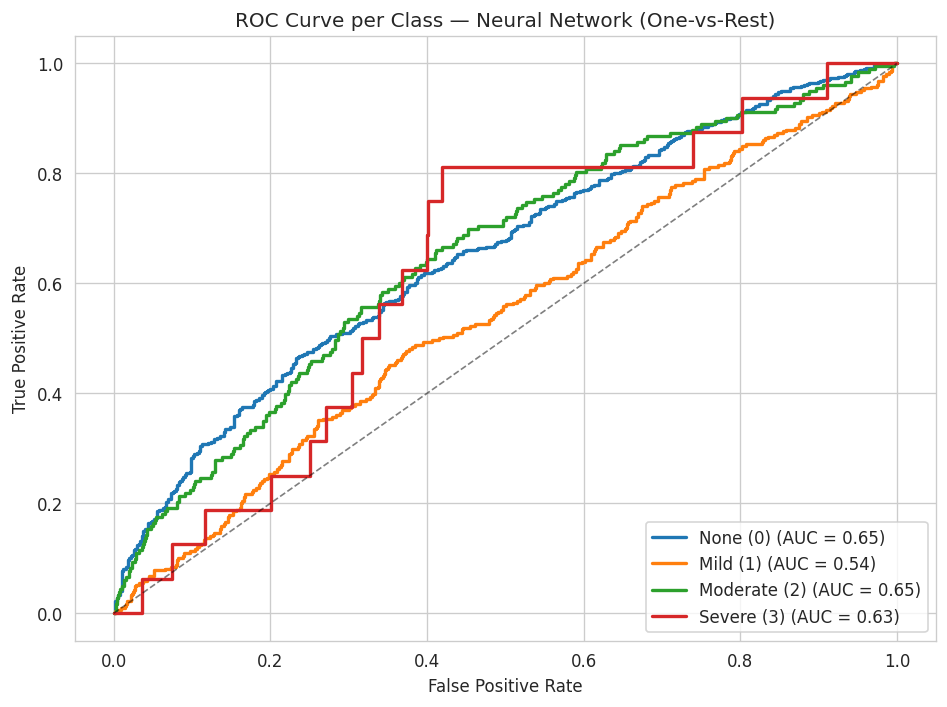

In [13]:
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_score    = best_mlp.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (class_label, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class — Neural Network (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Class separability is strongest for None (0) and Severe (3) — the two extremes of the ordinal scale — which the model discriminates most easily against all others. Mild (1) and Moderate (2) overlap more with adjacent classes, reflected in lower AUC values. Overall, the AUC scores confirm that the MLP has learned a meaningful probabilistic ranking despite the strong class imbalance.